# BÀI TẬP LỚN MÔN HỌC MÁY (CS320)

## PHẦN 1: BÀI TOÁN HỒI QUY (REGRESSION) - DỰ ĐOÁN GIÁ LAPTOP

## I. Nguồn dữ liệu và bối cảnh

* **Nguồn dữ liệu:** Bộ dữ liệu **Laptop Price Dataset Most Detailed** được thu thập từ nền tảng khoa học dữ liệu **Kaggle**.

* **Bài toán:** Xây dựng mô hình học máy để **dự đoán giá laptop** dựa trên các đặc trưng về thương hiệu, dòng máy, cấu hình phần cứng, màn hình, hệ điều hành, pin, cổng kết nối và các thông số kỹ thuật khác.

* **Biến mục tiêu cần dự đoán:** `Price (Rs)` - giá bán của laptop, tính theo đơn vị Rupee Ấn Độ. Đây là biến số liên tục nên bài toán thuộc nhóm **hồi quy**.

* **Công cụ sử dụng:** Áp dụng quy trình **Machine Learning Pipeline** gồm các bước: nạp dữ liệu, khám phá dữ liệu, xử lý giá trị thiếu, xử lý ngoại lệ, trích xuất đặc trưng số từ dữ liệu văn bản, mã hóa dữ liệu phân loại, chuẩn hóa dữ liệu, chia train/test, huấn luyện mô hình, đánh giá mô hình và lựa chọn mô hình tốt nhất.

* **Các mô hình sử dụng:** Linear Regression, Ridge Regression, Lasso Regression, KNN Regressor, Decision Tree Regressor và Random Forest Regressor. Ngoài ra, Dummy Regressor được sử dụng làm mô hình cơ sở để so sánh.

---

## II. Mô tả bộ dữ liệu (Data Dictionary)

Bộ dữ liệu `laptop_dataset_final.csv` gồm **8.198 quan sát** và **76 thuộc tính**. Mỗi dòng dữ liệu tương ứng với một mẫu laptop, còn mỗi cột mô tả một đặc điểm kỹ thuật hoặc thông tin bán hàng của laptop đó.

Một số nhóm thuộc tính chính trong bộ dữ liệu gồm:

* **Brand:** Thương hiệu laptop, ví dụ HP, Acer, Dell, MSI, Lenovo...
* **Model:** Mã hoặc tên model cụ thể của laptop.
* **Series:** Dòng sản phẩm của laptop, ví dụ Pavilion, Inspiron, Predator...
* **Thickness:** Độ dày của laptop, thường được ghi ở dạng văn bản như milimeter thickness.
* **Dimensions (WxDxH):** Kích thước tổng thể của laptop theo chiều rộng, chiều sâu và chiều cao.
* **Weight:** Khối lượng của laptop, thường được ghi kèm đơn vị kg.
* **Colors:** Màu sắc của laptop.
* **Operating System:** Hệ điều hành được cài đặt trên laptop, ví dụ Windows 10, Windows 11, DOS...
* **Operating System Type:** Kiểu hệ điều hành, ví dụ 64-bit.
* **Display Size:** Kích thước màn hình laptop, thường tính theo inch.
* **Display Resolution:** Độ phân giải màn hình.
* **Pixel Density:** Mật độ điểm ảnh của màn hình.
* **Display Type:** Loại màn hình.
* **Display Features:** Các đặc điểm bổ sung của màn hình.
* **Display Touchscreen:** Thông tin laptop có hỗ trợ màn hình cảm ứng hay không.
* **Processor:** Bộ vi xử lý của laptop.
* **Clock-speed:** Tốc độ xung nhịp của CPU.
* **Chipset:** Thông tin chipset nếu có.
* **Graphic Processor:** Bộ xử lý đồ họa hoặc card đồ họa.
* **Capacity:** Dung lượng RAM.
* **RAM Type:** Loại RAM, ví dụ DDR4, DDR5...
* **RAM Speed:** Tốc độ RAM.
* **SSD Capacity:** Dung lượng ổ cứng SSD.
* **SSD Type:** Loại SSD.
* **HDD Capacity:** Dung lượng ổ cứng HDD nếu có.
* **HDD Speed (RPM):** Tốc độ quay của ổ HDD.
* **Battery Cell:** Số cell pin.
* **Battery Type:** Loại pin.
* **Power Supply:** Công suất bộ sạc.
* **Wireless LAN:** Chuẩn kết nối Wi-Fi.
* **Bluetooth:** Thông tin hỗ trợ Bluetooth.
* **USB Type C, USB 3.0 slots, USB 2.0 slots:** Các cổng kết nối USB.
* **HDMI Ports:** Số lượng cổng HDMI.
* **Web-cam, Microphone, Speakers:** Các thông tin về webcam, micro và loa.
* **Keyboard, Backlit Keyboard:** Thông tin bàn phím và bàn phím có đèn nền.
* **Fingerprint scanner, Face Recognition:** Các tính năng bảo mật.
* **Warranty:** Thông tin bảo hành.
* **market_status:** Trạng thái sản phẩm trên thị trường, ví dụ Available.
* **Price (Rs):** Giá bán của laptop. Đây là **biến mục tiêu** mà mô hình cần học cách dự đoán.

---

## III. Lý do chọn bộ dữ liệu

Bộ dữ liệu Laptop Price Dataset Most Detailed được lựa chọn vì có số lượng mẫu tương đối lớn, gồm hơn 8.000 quan sát và 76 thuộc tính. So với các bộ dữ liệu mẫu nhỏ thường dùng để minh họa trong Scikit-learn, bộ dữ liệu này có tính thực tế cao hơn vì chứa nhiều thông tin khác nhau về cấu hình laptop, đồng thời có nhiều giá trị thiếu và nhiều cột dạng văn bản cần xử lý.

Bài toán dự đoán giá laptop cũng có ý nghĩa thực tiễn rõ ràng. Trong thực tế, giá laptop chịu ảnh hưởng bởi nhiều yếu tố như thương hiệu, CPU, RAM, SSD, màn hình, card đồ họa, hệ điều hành, pin và các tính năng bổ sung. Vì vậy, việc xây dựng mô hình hồi quy để dự đoán giá laptop giúp người học hiểu rõ hơn cách áp dụng học máy vào một bài toán định giá sản phẩm công nghệ.

---

## IV. Nguồn tham khảo

- **Nguồn dữ liệu:** [Laptop Price Dataset Most Detailed trên Kaggle](https://www.kaggle.com/datasets/vashisthrahul13/laptop-price-dataset-most-detailed)
* Tài liệu học phần Học máy: Chương hồi quy tuyến tính, KNN, Decision Tree và các nội dung liên quan đến xây dựng, huấn luyện, đánh giá mô hình học máy.
* Các thư viện sử dụng: Pandas, NumPy, Matplotlib và Scikit-learn.


## 1. Import thư viện

In [ ]:
# 1. IMPORT THƯ VIỆN

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Chia dữ liệu train/test
from sklearn.model_selection import train_test_split, GridSearchCV

# Tiền xử lý dữ liệu
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Các mô hình hồi quy
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Chỉ số đánh giá hồi quy
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

## 2. Nạp dữ liệu

In [ ]:
# 2. TẢI DỮ LIỆU TỪ KAGGLE VÀ NẠP DỮ LIỆU

!pip -q install kagglehub

import kagglehub
import os
import glob
import pandas as pd

# Tải dataset từ Kaggle
path = kagglehub.dataset_download("vashisthrahul13/laptop-price-dataset-most-detailed")

print("Đường dẫn dữ liệu:", path)

# Tìm các file CSV trong thư mục dataset
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)

print("Các file CSV tìm thấy:")
for f in csv_files:
    print(f)

# Đọc file CSV đầu tiên
df = pd.read_csv(csv_files[0], low_memory=False)

print("Kích thước dữ liệu:", df.shape)
df.head()

Using Colab cache for faster access to the 'laptop-price-dataset-most-detailed' dataset.
Đường dẫn dữ liệu: /kaggle/input/laptop-price-dataset-most-detailed
Các file CSV tìm thấy:
/kaggle/input/laptop-price-dataset-most-detailed/laptop_dataset_final.csv
Kích thước dữ liệu: (8198, 76)


,Brand,Model,Series,Thickness,Dimensions (WxDxH),Weight,Colors,Operating System,Operating System Type,Display Size,...,Lockport,Battery Life,USB Type C,Battery Capacity,Aspect Ratio,Number of Cores,SSD Interface,Fast Charging Support,market_status,Price (Rs)
0,HP,14-dv0055TU (2N1L1PA),Pavilion,17 Millimeter thickness,325 x 216 x 17 mm,1.41 Kg weight (Light-weight),Tranquil Pink,Windows 10 Home Basic,64-bit,14 Inches (35.56 cm),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Available,71990.0
1,Acer,PHN16-71 (NH.QLTSI.002),Predator Helios Neo 16,26.5 Millimeter thickness,361 x 279 x 26.5 mm,2.6 Kg weight,Black,Windows 11 Home Basic,NaN,16 Inches (40.64 cm),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Available,105999.0
2,Dell,15 5570 (A560126WIN9),Inspiron 15,22.7 Millimeter thickness,380 x 258 x 22.7 mm,2.2 Kg weight,Platinum Silver,Windows 10 Home Basic,64-bit,15.6 Inches (39.62 cm),...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Available,54999.0
3,MSI,GV62 7RD-2297XIN,NaN,29 Millimeter thickness,383 x 260 x 29 mm,2.2 Kg weight,Black,DOS,64-bit,15.6 Inches (39.62 cm),...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Available,67990.0
4,Dell,15 3515 (D560702WIN9BE),Inspiron 15,23 Millimeter thickness,358.50 x 17.50 x 23 mm,1.8 Kg weight,"Carbon Black, Platinum Silver",Windows 11 Home Basic,64-bit,15.6 Inches (39.62 cm),...,NaN,7 Hrs,2.0,NaN,NaN,NaN,NaN,NaN,Available,42210.0


In [ ]:
# Kiểm tra kích thước dữ liệu
df.shape

(8198, 76)

In [ ]:
# Kiểm tra thông tin tổng quan
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8198 entries, 0 to 8197
Data columns (total 76 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Brand                       8198 non-null   object 
 1   Model                       8198 non-null   object 
 2   Series                      7105 non-null   object 
 3   Thickness                   7518 non-null   object 
 4   Dimensions (WxDxH)          7516 non-null   object 
 5   Weight                      7891 non-null   object 
 6   Colors                      8022 non-null   object 
 7   Operating System            8198 non-null   object 
 8   Operating System Type       4678 non-null   object 
 9   Display Size                8195 non-null   object 
 10  Display Resolution          8166 non-null   object 
 11  Pixel Density               8164 non-null   object 
 12  Display Type                4308 non-null   object 
 13  Display Features            8066 

In [ ]:
df.isnull().sum()

,0
Brand,0
Model,0
Series,1093
Thickness,680
Dimensions (WxDxH),682
...,...
Number of Cores,5273
SSD Interface,6145
Fast Charging Support,7258
market_status,0


## 3. Kiểm tra giá trị thiếu

In [ ]:
# 3. KIỂM TRA GIÁ TRỊ THIẾU

missing_df = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Ratio": df.isnull().mean()
}).sort_values(by="Missing_Count", ascending=False)

missing_df

,Missing_Count,Missing_Ratio
Fast Charging Support,7258,0.885338
Thunderbolt Port,7205,0.878873
Chipset,7147,0.871798
Aspect Ratio,6869,0.837887
Lockport,6664,0.812881
...,...,...
Brand,0,0.000000
Operating System,0,0.000000
Capacity,0,0.000000
Processor,0,0.000000


In [ ]:
# Hiển thị 20 cột có nhiều giá trị thiếu nhất
missing_df.head(20)

,Missing_Count,Missing_Ratio
Fast Charging Support,7258,0.885338
Thunderbolt Port,7205,0.878873
Chipset,7147,0.871798
Aspect Ratio,6869,0.837887
Lockport,6664,0.812881
HDD Type,6469,0.789095
HDD Speed(RPM),6462,0.788241
HDD Capacity,6344,0.773847
SSD Interface,6145,0.749573
USB 3.0 slots,5975,0.728836


### Nhận xét

Kết quả kiểm tra cho thấy bộ dữ liệu có khá nhiều cột bị thiếu dữ liệu. Đặc biệt, một số cột như `Fast Charging Support`, `SSD Interface`, `Number of Cores` có số lượng giá trị thiếu lớn. Biến mục tiêu `Price (Rs)` cũng có 21 giá trị thiếu, vì đây là cột cần dự đoán nên các dòng bị thiếu giá sẽ được loại bỏ. Đối với các cột đầu vào, bài làm không xóa toàn bộ dòng bị thiếu mà sử dụng kỹ thuật imputation trong pipeline để điền giá trị phù hợp, giúp tránh mất quá nhiều dữ liệu.

## 4. Xử lý cột target Price (Rs)

In [ ]:
# 4. XỬ LÝ BIẾN MỤC TIÊU

target_col = "Price (Rs)"

# Kiểm tra số giá trị thiếu ở cột target
print("Số giá trị thiếu ở target:", df[target_col].isnull().sum())

# Xóa các dòng không có giá laptop
df = df.dropna(subset=[target_col]).copy()

# Ép kiểu giá về dạng số
df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

# Nếu sau khi ép kiểu còn thiếu thì tiếp tục xóa
df = df.dropna(subset=[target_col]).copy()

print("Kích thước dữ liệu sau khi xử lý target:", df.shape)

Số giá trị thiếu ở target: 21
Kích thước dữ liệu sau khi xử lý target: (8177, 76)


### Nhận xét

Cột `Price (Rs)` là biến mục tiêu của bài toán nên không thể để trống. Những dòng không có giá laptop sẽ không giúp mô hình học được mối quan hệ giữa đặc trưng và giá bán, vì vậy các dòng này được loại bỏ. Sau khi xử lý, bộ dữ liệu vẫn còn hơn 8.000 mẫu, đủ lớn để huấn luyện và đánh giá mô hình hồi quy.

## 5. Phân tích sơ bộ biến mục tiêu

In [ ]:
# 5. PHÂN TÍCH BIẾN MỤC TIÊU

df[target_col].describe()

,Price (Rs)
count,8177.000000
mean,80852.045738
std,59390.288254
min,8990.000000
25%,42490.000000
50%,64989.000000
75%,96990.000000
max,499990.000000


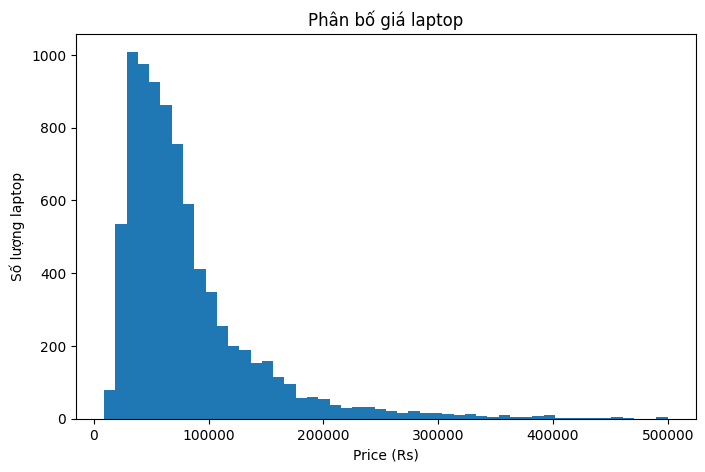

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df[target_col], bins=50)
plt.xlabel("Price (Rs)")
plt.ylabel("Số lượng laptop")
plt.title("Phân bố giá laptop")
plt.show()

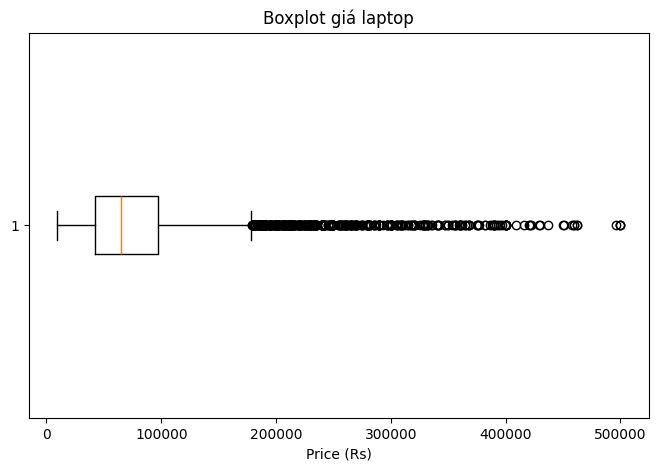

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(df[target_col], vert=False)
plt.xlabel("Price (Rs)")
plt.title("Boxplot giá laptop")
plt.show()

### Nhận xét

Biểu đồ phân bố giá laptop giúp quan sát mức giá phổ biến trong bộ dữ liệu. Nếu biểu đồ lệch phải, điều đó cho thấy phần lớn laptop nằm ở phân khúc giá thấp hoặc trung bình, trong khi một số mẫu laptop cao cấp có giá rất cao. Boxplot giúp phát hiện các giá trị ngoại lệ. Trong bài toán dự đoán giá, outlier là điều thường gặp vì laptop gaming, workstation hoặc laptop cao cấp có thể có giá cao hơn nhiều so với mặt bằng chung.

## 6. Xử lý outlier ở giá laptop

In [ ]:
# 6. XỬ LÝ OUTLIER Ở GIÁ LAPTOP

before_outlier_count = df.shape[0]

Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Ngưỡng dưới:", lower_bound)
print("Ngưỡng trên:", upper_bound)

df = df[(df[target_col] >= lower_bound) & (df[target_col] <= upper_bound)].copy()

after_outlier_count = df.shape[0]
removed_count = before_outlier_count - after_outlier_count
removed_ratio = removed_count / before_outlier_count * 100

print("Số dòng trước khi xử lý outlier:", before_outlier_count)
print("Số dòng sau khi xử lý outlier:", after_outlier_count)
print("Số dòng bị loại:", removed_count)
print("Tỷ lệ bị loại: {:.2f}%".format(removed_ratio))

Ngưỡng dưới: -39260.0
Ngưỡng trên: 178740.0
Số dòng trước khi xử lý outlier: 8177
Số dòng sau khi xử lý outlier: 7665
Số dòng bị loại: 512
Tỷ lệ bị loại: 6.26%


### Nhận xét

Giá laptop có sự chênh lệch lớn giữa các phân khúc, đặc biệt giữa laptop phổ thông, laptop gaming, workstation và các dòng cao cấp. Một số mẫu có giá quá cao hoặc quá thấp so với phần lớn dữ liệu có thể làm tăng sai số của mô hình, đặc biệt là MSE và RMSE vì các chỉ số này nhạy với lỗi lớn. Vì vậy, bài làm sử dụng phương pháp IQR để loại bỏ các điểm cực trị quá xa so với phân bố chung.

Sau khi xử lý outlier, dữ liệu giảm từ 8.177 dòng xuống còn 7.665 dòng, tức là loại bỏ khoảng 512 dòng, tương đương khoảng 6,2% dữ liệu. Đây là tỷ lệ chấp nhận được và không làm mất phần lớn dữ liệu. Tuy nhiên, việc loại bỏ outlier cũng có hạn chế là mô hình có thể phù hợp hơn với phân khúc giá phổ biến, còn khả năng dự đoán laptop siêu cao cấp hoặc cấu hình đặc biệt có thể bị hạn chế.

## 7. Tạo thêm một số đặc trưng số từ cột dạng chữ

In [ ]:
# 7. TẠO ĐẶC TRƯNG SỐ TỪ CỘT TEXT

import re

def extract_first_number(value):
    """
    Hàm lấy số đầu tiên trong một chuỗi.
    Ví dụ:
    '1.41 Kg weight' -> 1.41
    '14 Inches (35.56 cm)' -> 14
    """
    if pd.isnull(value):
        return np.nan

    value = str(value)
    numbers = re.findall(r"\d+\.?\d*", value)

    if len(numbers) == 0:
        return np.nan

    return float(numbers[0])


def extract_storage_to_gb(value):
    """
    Hàm chuyển dung lượng lưu trữ về đơn vị GB.
    Ví dụ:
    '512 GB' -> 512
    '1 TB' -> 1024
    """
    if pd.isnull(value):
        return np.nan

    text = str(value).lower()
    numbers = re.findall(r"\d+\.?\d*", text)

    if len(numbers) == 0:
        return np.nan

    number = float(numbers[0])

    if "tb" in text:
        return number * 1024
    elif "gb" in text:
        return number
    elif "mb" in text:
        return number / 1024
    else:
        return number


# Tạo các cột số mới nếu cột gốc tồn tại trong dữ liệu
if "Weight" in df.columns:
    df["Weight_kg"] = df["Weight"].apply(extract_first_number)

if "Thickness" in df.columns:
    df["Thickness_mm"] = df["Thickness"].apply(extract_first_number)

if "Display Size" in df.columns:
    df["Display_Size_inch"] = df["Display Size"].apply(extract_first_number)

if "RAM Speed" in df.columns:
    df["RAM_Speed_num"] = df["RAM Speed"].apply(extract_first_number)

if "Clock-speed" in df.columns:
    df["Clock_Speed_num"] = df["Clock-speed"].apply(extract_first_number)

if "SSD Capacity" in df.columns:
    df["SSD_Capacity_GB"] = df["SSD Capacity"].apply(extract_storage_to_gb)

if "HDD Capacity" in df.columns:
    df["HDD_Capacity_GB"] = df["HDD Capacity"].apply(extract_storage_to_gb)

if "Battery Life" in df.columns:
    df["Battery_Life_hours"] = df["Battery Life"].apply(extract_first_number)

if "Refresh Rate" in df.columns:
    df["Refresh_Rate_num"] = df["Refresh Rate"].apply(extract_first_number)

if "Brightness" in df.columns:
    df["Brightness_num"] = df["Brightness"].apply(extract_first_number)

print("Các cột sau khi tạo thêm đặc trưng:", df.shape)

Các cột sau khi tạo thêm đặc trưng: (7665, 86)


### Nhận xét

Một số đặc trưng quan trọng của laptop ban đầu đang ở dạng văn bản, ví dụ cân nặng, kích thước màn hình, dung lượng SSD hoặc thời lượng pin. Nếu giữ nguyên toàn bộ dưới dạng chữ, mô hình khó học được ý nghĩa số học của các đặc trưng này. Vì vậy, bài làm trích xuất phần số từ các cột văn bản để tạo thêm các biến số mới như `Weight_kg`, `Display_Size_inch`, `SSD_Capacity_GB`. Đây là bước feature engineering giúp cải thiện chất lượng dữ liệu đầu vào.

In [ ]:
#  BỔ SUNG THÊM MỘT SỐ ĐẶC TRƯNG SỐ

def extract_memory_to_gb(value):
    """
    Chuyển dung lượng bộ nhớ về GB.
    Ví dụ:
    '8 GB'  -> 8
    '16 GB' -> 16
    '1 TB'  -> 1024
    """
    if pd.isnull(value):
        return np.nan

    text = str(value).lower()
    numbers = re.findall(r"\d+\.?\d*", text)

    if len(numbers) == 0:
        return np.nan

    number = float(numbers[0])

    if "tb" in text:
        return number * 1024
    elif "gb" in text:
        return number
    elif "mb" in text:
        return number / 1024
    else:
        return number


def extract_power_watt(value):
    """
    Lấy công suất sạc, thường có đơn vị W hoặc Watt.
    Ví dụ:
    '65 W' -> 65
    """
    return extract_first_number(value)


# RAM chính
if "Capacity" in df.columns:
    df["RAM_GB"] = df["Capacity"].apply(extract_memory_to_gb)

# Cache CPU
if "Cache" in df.columns:
    df["Cache_num"] = df["Cache"].apply(extract_first_number)

# Graphic memory
if "Graphics Memory" in df.columns:
    df["Graphics_Memory_GB"] = df["Graphics Memory"].apply(extract_memory_to_gb)

# Power supply
if "Power Supply" in df.columns:
    df["Power_Supply_W"] = df["Power Supply"].apply(extract_power_watt)

# Battery cell
if "Battery Cell" in df.columns:
    df["Battery_Cell_num"] = df["Battery Cell"].apply(extract_first_number)

# Battery capacity
if "Battery Capacity" in df.columns:
    df["Battery_Capacity_num"] = df["Battery Capacity"].apply(extract_first_number)

# Number of cores nếu đang bị thiếu nhiều nhưng vẫn có dữ liệu dạng text/số
if "Number of Cores" in df.columns:
    df["Number_Of_Cores_num"] = df["Number of Cores"].apply(extract_first_number)

print("Kích thước dữ liệu sau khi bổ sung feature engineering:", df.shape)

Kích thước dữ liệu sau khi bổ sung feature engineering: (7665, 93)


### Nhận xét

Ở bước này, bài làm tiếp tục trích xuất thêm một số đặc trưng số quan trọng từ các cột dạng văn bản, ví dụ dung lượng RAM, bộ nhớ đồ họa, công suất sạc, số cell pin và cache CPU. Các thông tin này có liên quan trực tiếp đến cấu hình phần cứng của laptop và có thể ảnh hưởng đến giá bán. Việc tạo thêm các biến số giúp mô hình học tốt hơn ý nghĩa định lượng của dữ liệu thay vì chỉ xem các thông tin này như văn bản phân loại.

## 8. Loại bỏ cột không phù hợp hoặc quá thiếu dữ liệu

In [ ]:
# 8. LOẠI BỎ CỘT KHÔNG PHÙ HỢP

# Xóa các cột có tỷ lệ thiếu quá cao, ví dụ trên 60%
missing_ratio = df.isnull().mean()
high_missing_cols = missing_ratio[missing_ratio > 0.6].index.tolist()

# Không được xóa target
if target_col in high_missing_cols:
    high_missing_cols.remove(target_col)

print("Các cột bị loại do thiếu quá nhiều dữ liệu:")
print(high_missing_cols)

df = df.drop(columns=high_missing_cols)

# Một số cột định danh hoặc quá chi tiết dễ gây nhiễu/overfit
drop_cols = []

for col in ["Model", "Dimensions (WxDxH)"]:
    if col in df.columns:
        drop_cols.append(col)

df = df.drop(columns=drop_cols)

print("Các cột định danh/quá chi tiết bị loại:", drop_cols)
print("Kích thước dữ liệu sau khi loại cột:", df.shape)

Các cột bị loại do thiếu quá nhiều dữ liệu:
['Chipset', 'SSD Type', 'Other Networking Options', 'Audio Solution', 'Face Recognition', 'Refresh Rate', 'Brightness', 'Graphics Memory', 'Expandable Memory', 'Thunderbolt Port', 'HDD Capacity', 'HDD Speed(RPM)', 'HDD Type', 'USB 3.0 slots', 'Lockport', 'Battery Life', 'Battery Capacity', 'Aspect Ratio', 'Number of Cores', 'SSD Interface', 'Fast Charging Support', 'HDD_Capacity_GB', 'Battery_Life_hours', 'Refresh_Rate_num', 'Brightness_num', 'Graphics_Memory_GB', 'Battery_Capacity_num', 'Number_Of_Cores_num']
Các cột định danh/quá chi tiết bị loại: ['Model', 'Dimensions (WxDxH)']
Kích thước dữ liệu sau khi loại cột: (7665, 63)


### Nhận xét

Một số cột có tỷ lệ giá trị thiếu quá cao, nếu giữ lại có thể làm quá trình tiền xử lý phức tạp và ít mang lại thông tin hữu ích. Vì vậy, các cột có trên 60% giá trị thiếu được loại bỏ. Ngoài ra, một số cột như `Model` hoặc `Dimensions (WxDxH)` có thể quá chi tiết hoặc chứa thông tin dạng chuỗi khó chuẩn hóa, dễ làm mô hình học thuộc dữ liệu thay vì học quy luật tổng quát. Việc loại bỏ các cột này giúp mô hình ổn định hơn và giảm nguy cơ overfitting.

## 9. Tách X và y

In [ ]:
# 9. TÁCH FEATURES VÀ TARGET

X = df.drop(columns=[target_col])
y = df[target_col]

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)

Kích thước X: (7665, 62)
Kích thước y: (7665,)


In [ ]:
# Kiểm tra các kiểu dữ liệu trong X
X.dtypes.value_counts()

,count
object,47
float64,15


### Nhận xét

Sau khi xử lý dữ liệu, tập đặc trưng `X` gồm các thông tin mô tả laptop, còn biến mục tiêu `y` là giá laptop. Đây là cách tách dữ liệu cơ bản trong bài toán học có giám sát: mô hình học từ các đặc trưng đầu vào để dự đoán giá trị đầu ra.

## 10. Chia train/test

In [ ]:
# 10. CHIA TRAIN/TEST

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (6132, 62)
X_test: (1533, 62)
y_train: (6132,)
y_test: (1533,)


### Nhận xét

Dữ liệu được chia thành 80% dùng để huấn luyện và 20% dùng để kiểm tra. Tập huấn luyện giúp mô hình học mối quan hệ giữa cấu hình laptop và giá bán, còn tập kiểm tra được dùng để đánh giá khả năng dự đoán của mô hình trên dữ liệu chưa từng thấy.

## 11. Xây dựng tiền xử lý bằng Pipeline

In [ ]:
# 11. XÂY DỰNG TIỀN XỬ LÝ DỮ LIỆU

# Xác định cột số và cột chữ
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Số cột numeric:", len(numeric_features))
print("Số cột categorical:", len(categorical_features))

print("Một số cột numeric:", numeric_features[:10])
print("Một số cột categorical:", categorical_features[:10])

Số cột numeric: 15
Số cột categorical: 47
Một số cột numeric: ['Wi-Fi Version', 'Bluetooth Version', 'USB 2.0 slots', 'Ethernet ports', 'USB Type C', 'Weight_kg', 'Thickness_mm', 'Display_Size_inch', 'RAM_Speed_num', 'Clock_Speed_num']
Một số cột categorical: ['Brand', 'Series', 'Thickness', 'Weight', 'Colors', 'Operating System', 'Operating System Type', 'Display Size', 'Display Resolution', 'Pixel Density']


In [ ]:
# Pipeline xử lý cột số:
# - Điền giá trị thiếu bằng median
# - Chuẩn hóa dữ liệu bằng StandardScaler
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline xử lý cột chữ:
# - Điền giá trị thiếu bằng giá trị xuất hiện nhiều nhất
# - One-Hot Encoding để biến chữ thành số
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=10))
])

# Gộp xử lý cột số và cột chữ
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### Nhận xét

Bộ dữ liệu laptop có cả cột số và cột chữ. Các cột số được điền giá trị thiếu bằng median và chuẩn hóa để đưa về cùng thang đo. Các cột chữ được điền bằng giá trị xuất hiện nhiều nhất, sau đó mã hóa bằng One-Hot Encoding để mô hình học máy có thể sử dụng. Toàn bộ quá trình tiền xử lý được đặt trong Pipeline nhằm tránh rò rỉ dữ liệu, vì các bước xử lý chỉ được học từ tập train rồi áp dụng cho tập test.

## 12. Xây dựng hàm đánh giá mô hình hồi quy

In [ ]:
# 12. HÀM ĐÁNH GIÁ MÔ HÌNH HỒI QUY

def evaluate_regression_model(model_name, y_true, y_pred):
    """
    Hàm đánh giá mô hình hồi quy bằng các chỉ số:
    - MAE: Sai số tuyệt đối trung bình
    - MSE: Sai số bình phương trung bình
    - RMSE: Căn bậc hai của MSE
    - R2: Mức độ giải thích biến thiên của mô hình
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

### Nhận xét

Đối với bài toán hồi quy, mô hình được đánh giá bằng MAE, MSE, RMSE và R². MAE cho biết trung bình mô hình dự đoán lệch bao nhiêu so với giá thực tế. MSE và RMSE phạt mạnh hơn các lỗi lớn. R² cho biết mô hình giải thích được bao nhiêu phần biến thiên của giá laptop. Mô hình tốt là mô hình có MAE, MSE, RMSE thấp và R² cao.

## 13. Huấn luyện Dummy Regressor

In [ ]:
results = []
trained_models = {}

from sklearn.dummy import DummyRegressor

dummy_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

dummy_model.fit(X_train, y_train)

y_pred_dummy = dummy_model.predict(X_test)

dummy_result = evaluate_regression_model(
    "Dummy Regressor",
    y_test,
    y_pred_dummy
)

results.append(dummy_result)
trained_models["Dummy Regressor"] = dummy_model

dummy_result

{'Model': 'Dummy Regressor',
 'MAE': 28806.244180539543,
 'MSE': 1321942579.171005,
 'RMSE': np.float64(36358.5282866483),
 'R2': -1.1127019265977367e-05}

### Nhận xét:

Dummy Regressor là mô hình cơ sở, dự đoán theo giá trị trung bình của tập huấn luyện. Mô hình này không học quy luật thực sự từ dữ liệu mà dùng để làm mốc so sánh. Nếu các mô hình học máy tốt hơn Dummy Regressor rõ rệt thì có thể kết luận rằng mô hình đã học được mối quan hệ giữa các đặc trưng và giá laptop.

## 14. Huấn luyện Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

linear_result = evaluate_regression_model(
    "Linear Regression",
    y_test,
    y_pred_linear
)

results.append(linear_result)
trained_models["Linear Regression"] = linear_model

linear_result

{'Model': 'Linear Regression',
 'MAE': 9858.103717610338,
 'MSE': 197959561.25736898,
 'RMSE': np.float64(14069.810277945078),
 'R2': 0.850249347379851}

### Nhận xét:

Linear Regression là mô hình hồi quy tuyến tính cơ bản. Mô hình giả định rằng giá laptop có thể được dự đoán bằng sự kết hợp tuyến tính của các đặc trưng như RAM, SSD, CPU, GPU, kích thước màn hình, cân nặng và các thông tin cấu hình khác. Đây là mô hình dễ giải thích và được dùng làm mô hình nền để so sánh với các mô hình phức tạp hơn.

## 15. Huấn luyện Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

ridge_result = evaluate_regression_model(
    "Ridge Regression",
    y_test,
    y_pred_ridge
)

results.append(ridge_result)
trained_models["Ridge Regression"] = ridge_model

ridge_result

{'Model': 'Ridge Regression',
 'MAE': 9650.875515812924,
 'MSE': 190611266.1960296,
 'RMSE': np.float64(13806.203902450145),
 'R2': 0.8558081189496178}

### Nhận xét:

Ridge Regression là mô hình hồi quy tuyến tính có thêm regularization. Cơ chế này giúp hạn chế việc hệ số của mô hình quá lớn, từ đó giảm nguy cơ overfitting. Ridge thường phù hợp khi dữ liệu sau One-Hot Encoding có nhiều đặc trưng.

## 16. Huấn luyện Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Lasso(alpha=0.01, max_iter=5000))
])

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

lasso_result = evaluate_regression_model(
    "Lasso Regression",
    y_test,
    y_pred_lasso
)

results.append(lasso_result)
trained_models["Lasso Regression"] = lasso_model

lasso_result

{'Model': 'Lasso Regression',
 'MAE': 9840.546563275862,
 'MSE': 196602757.39754748,
 'RMSE': np.float64(14021.510524816771),
 'R2': 0.8512757300521264}

### Nhận xét:

Lasso Regression cũng là mô hình hồi quy tuyến tính có regularization. Khác với Ridge, Lasso có thể làm một số hệ số tiến gần về 0, từ đó giúp giảm ảnh hưởng của các đặc trưng ít quan trọng. Tuy nhiên, nếu alpha chọn chưa phù hợp, mô hình có thể bị đơn giản hóa quá mức.

## 17. Huấn luyện KNN Regressor

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

knn_result = evaluate_regression_model(
    "KNN Regressor",
    y_test,
    y_pred_knn
)

results.append(knn_result)
trained_models["KNN Regressor"] = knn_model

knn_result

{'Model': 'KNN Regressor',
 'MAE': 10534.757469015003,
 'MSE': 243233752.95420748,
 'RMSE': np.float64(15595.953095409317),
 'R2': 0.8160007376618452}

### Nhận xét:

KNN Regressor dự đoán giá laptop dựa trên các mẫu dữ liệu gần nhất trong tập huấn luyện. Mô hình này dễ hiểu nhưng có thể bị ảnh hưởng bởi việc chuẩn hóa dữ liệu và số lượng láng giềng được chọn.

## 18. Huấn luyện Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeRegressor(
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

tree_result = evaluate_regression_model(
    "Decision Tree Regressor",
    y_test,
    y_pred_tree
)

results.append(tree_result)
trained_models["Decision Tree Regressor"] = tree_model

tree_result

{'Model': 'Decision Tree Regressor',
 'MAE': 12833.18895412046,
 'MSE': 367750160.54562587,
 'RMSE': np.float64(19176.81309669638),
 'R2': 0.7218076955056797}

### Nhận xét:

Decision Tree Regressor học các luật chia dữ liệu để dự đoán giá laptop. Mô hình này có khả năng học quan hệ phi tuyến, nhưng nếu cây quá sâu thì dễ bị overfitting, tức là học quá kỹ tập train và dự đoán kém hơn trên tập test.

## 19. Huấn luyện Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_result = evaluate_regression_model(
    "Random Forest Regressor",
    y_test,
    y_pred_rf
)

results.append(rf_result)
trained_models["Random Forest Regressor"] = rf_model

rf_result

{'Model': 'Random Forest Regressor',
 'MAE': 9952.771038874911,
 'MSE': 215011843.6415252,
 'RMSE': np.float64(14663.282157877384),
 'R2': 0.837349791533844}

### Nhận xét:

Random Forest Regressor kết hợp nhiều cây quyết định để tăng độ ổn định và giảm overfitting so với một cây quyết định đơn lẻ. Đây thường là mô hình mạnh với dữ liệu dạng bảng vì có thể học được các quan hệ phi tuyến giữa cấu hình laptop và giá bán.

## 20. So sánh kết quả các mô hình

In [ ]:
results_df = pd.DataFrame(results)

# Nếu cột R2 tên là "R2"
if "R2" in results_df.columns:
    results_df = results_df.sort_values(by="R2", ascending=False)

# Nếu cột R2 tên là "R2-score" hoặc "R²" thì tự xử lý
elif "R2-score" in results_df.columns:
    results_df = results_df.sort_values(by="R2-score", ascending=False)

elif "R²" in results_df.columns:
    results_df = results_df.sort_values(by="R²", ascending=False)

results_df

,Model,MAE,MSE,RMSE,R2
2,Ridge Regression,9650.875516,1.906113e+08,13806.203902,0.855808
3,Lasso Regression,9840.546563,1.966028e+08,14021.510525,0.851276
1,Linear Regression,9858.103718,1.979596e+08,14069.810278,0.850249
6,Random Forest Regressor,9952.771039,2.150118e+08,14663.282158,0.837350
4,KNN Regressor,10534.757469,2.432338e+08,15595.953095,0.816001
5,Decision Tree Regressor,12833.188954,3.677502e+08,19176.813097,0.721808
0,Dummy Regressor,28806.244181,1.321943e+09,36358.528287,-0.000011


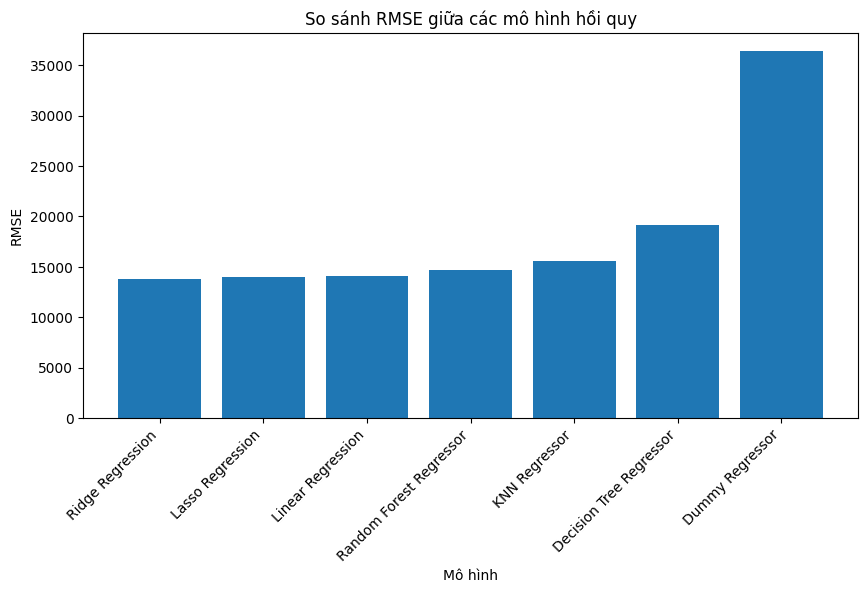

In [ ]:
# Sắp xếp theo RMSE tăng dần vì RMSE càng thấp càng tốt
results_df_sorted_rmse = results_df.sort_values(by="RMSE", ascending=True)

plt.figure(figsize=(10, 5))
plt.bar(results_df_sorted_rmse["Model"], results_df_sorted_rmse["RMSE"])
plt.xlabel("Mô hình")
plt.ylabel("RMSE")
plt.title("So sánh RMSE giữa các mô hình hồi quy")
plt.xticks(rotation=45, ha="right")
plt.show()

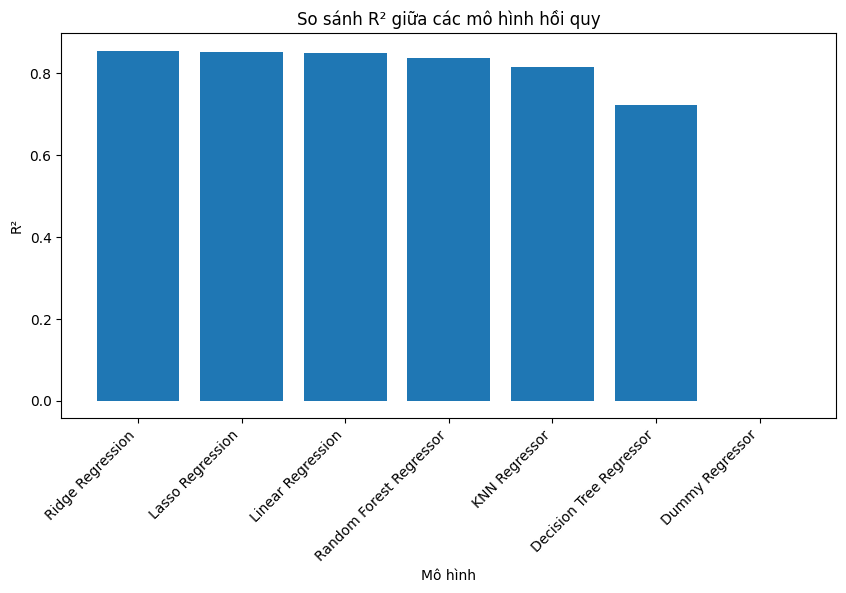

In [ ]:
# Sắp xếp theo R2 giảm dần vì R2 càng cao càng tốt
results_df_sorted_r2 = results_df.sort_values(by="R2", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(results_df_sorted_r2["Model"], results_df_sorted_r2["R2"])
plt.xlabel("Mô hình")
plt.ylabel("R²")
plt.title("So sánh R² giữa các mô hình hồi quy")
plt.xticks(rotation=45, ha="right")
plt.show()

### Nhận xét

Kết quả so sánh các mô hình ban đầu cho thấy **Ridge Regression** là mô hình có hiệu quả tốt nhất trước khi tối ưu siêu tham số, với **MAE khoảng 9.651**, **RMSE khoảng 13.806** và **R² khoảng 0.856**. So với **Dummy Regressor**, mô hình Ridge Regression giảm RMSE từ khoảng **36.359** xuống còn khoảng **13.806**, cho thấy mô hình đã học được mối quan hệ giữa các đặc trưng laptop và giá bán thay vì chỉ dự đoán theo giá trị trung bình.

Các mô hình tuyến tính như Linear Regression, Ridge Regression và Lasso Regression đều cho kết quả khá tốt. Trong đó, Ridge Regression có kết quả tốt nhất nhờ cơ chế điều chuẩn, giúp hạn chế overfitting khi dữ liệu sau One-Hot Encoding có nhiều đặc trưng. Các mô hình phức tạp hơn như Decision Tree và Random Forest không nhất thiết vượt trội hơn, cho thấy mô hình phức tạp hơn chưa chắc luôn phù hợp hơn với cùng một bộ dữ liệu.


## 21. Chọn mô hình tốt nhất

In [ ]:
# Ưu tiên chọn mô hình có R2 cao nhất
if "R2" in results_df.columns:
    best_model_name = results_df.iloc[0]["Model"]

elif "R2-score" in results_df.columns:
    best_model_name = results_df.iloc[0]["Model"]

elif "R²" in results_df.columns:
    best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

# Tạo dự đoán cho mô hình tốt nhất ban đầu
y_pred_best = best_model.predict(X_test)

print("Mô hình tốt nhất là:", best_model_name)
results_df.iloc[0]

Mô hình tốt nhất là: Ridge Regression


,2
Model,Ridge Regression
MAE,9650.875516
MSE,190611266.19603
RMSE,13806.203902
R2,0.855808


### Nhận xét:

Dựa trên bảng so sánh kết quả, **Ridge Regression** là mô hình tốt nhất ban đầu với MAE khoảng 9.651, RMSE khoảng 13.806 và R² khoảng 0.856. Mô hình này được chọn để phân tích sâu hơn vì có sai số thấp và khả năng giải thích dữ liệu tốt nhất trong các mô hình ban đầu.

## 22. Biểu đồ giá thực tế và giá dự đoán

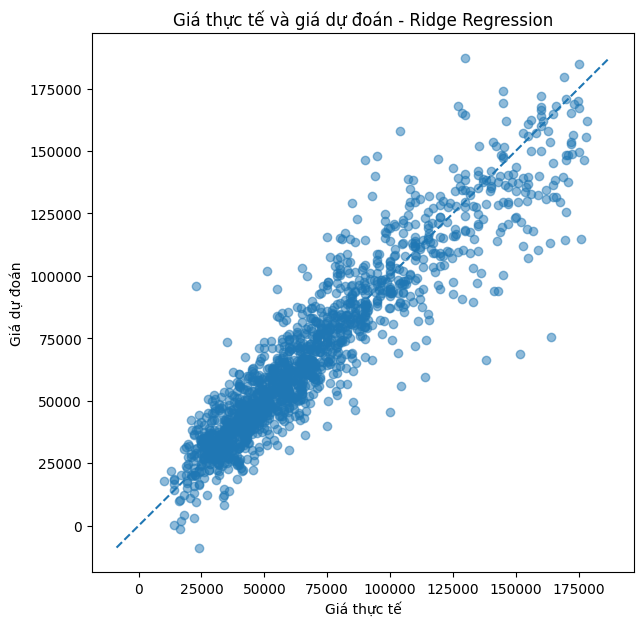

In [ ]:
# 22. BIỂU ĐỒ GIÁ THỰC TẾ VÀ GIÁ DỰ ĐOÁN

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.5)

min_value = min(y_test.min(), y_pred_best.min())
max_value = max(y_test.max(), y_pred_best.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Giá thực tế")
plt.ylabel("Giá dự đoán")
plt.title(f"Giá thực tế và giá dự đoán - {best_model_name}")
plt.show()

### Nhận xét:

Biểu đồ giá thực tế và giá dự đoán cho thấy mức độ chênh lệch giữa giá laptop thực tế và giá do mô hình dự đoán. Nếu các điểm dữ liệu nằm gần đường chéo thì mô hình dự đoán càng chính xác.

Ở bước này, mô hình đang được phân tích là mô hình tốt nhất ban đầu được chọn từ bảng so sánh kết quả. Biểu đồ cho thấy mô hình có khả năng dự đoán tương đối tốt, tuy vẫn còn một số điểm lệch xa đường chéo ở các mẫu laptop có giá trị đặc biệt.

## 23. Phân tích phần dư

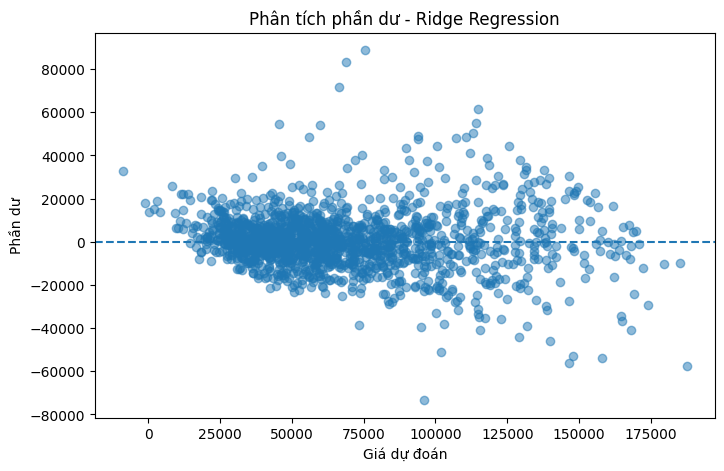

In [ ]:
# 23. PHÂN TÍCH PHẦN DƯ

residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_best, residuals, alpha=0.5)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Giá dự đoán")
plt.ylabel("Phần dư")
plt.title(f"Phân tích phần dư - {best_model_name}")
plt.show()

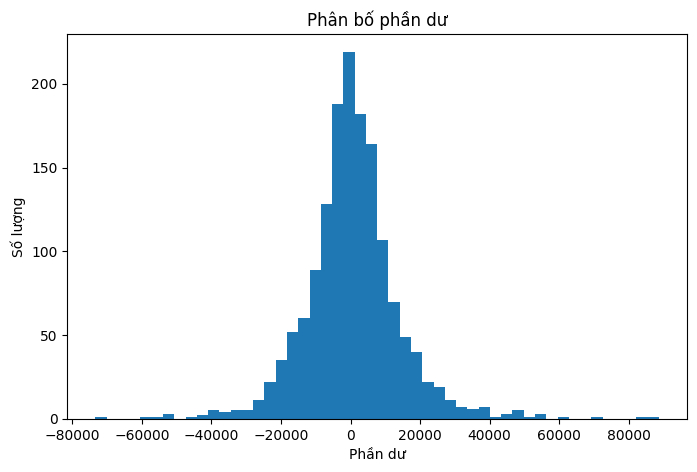

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50)

plt.xlabel("Phần dư")
plt.ylabel("Số lượng")
plt.title("Phân bố phần dư")
plt.show()

### Nhận xét:

Phần dư là chênh lệch giữa giá thực tế và giá dự đoán. Nếu phần dư phân bố quanh đường 0 thì mô hình dự đoán tương đối ổn định.

Biểu đồ phần dư cho thấy sai số của mô hình chủ yếu tập trung quanh 0, tuy vẫn có một số sai số lớn. Điều này có thể xảy ra với các laptop có cấu hình đặc biệt, thương hiệu cao cấp hoặc mức giá khác biệt so với phần lớn dữ liệu.

## 24. Tối ưu mô hình Ridge Regression

In [ ]:
# 24. TỐI ƯU MÔ HÌNH RIDGE REGRESSION

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge())
])

ridge_params = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 50, 100]
}

ridge_search = GridSearchCV(
    ridge_pipeline,
    param_grid=ridge_params,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

ridge_search.fit(X_train, y_train)

print("Alpha tốt nhất:", ridge_search.best_params_)
print("R2 CV tốt nhất:", ridge_search.best_score_)

Alpha tốt nhất: {'model__alpha': 10}
R2 CV tốt nhất: 0.8410473064570688


In [ ]:
# Đánh giá Ridge Regression sau tối ưu

ridge_best_model = ridge_search.best_estimator_
y_pred_ridge_tuned = ridge_best_model.predict(X_test)

ridge_tuned_result = evaluate_regression_model(
    "Ridge Regression - Tuned",
    y_test,
    y_pred_ridge_tuned
)

ridge_tuned_result

{'Model': 'Ridge Regression - Tuned',
 'MAE': 9557.383524423967,
 'MSE': 188572063.65450358,
 'RMSE': np.float64(13732.154370473105),
 'R2': 0.8573507163845615}

### Nhận xét:

Sau khi Ridge Regression cho kết quả tốt ở bước so sánh mô hình, bài làm tiếp tục tối ưu tham số `alpha` bằng GridSearchCV. Tham số `alpha` giúp kiểm soát mức độ điều chuẩn của Ridge Regression.

Việc tối ưu này nhằm kiểm tra xem Ridge Regression sau khi điều chỉnh tham số có thể cải thiện kết quả so với mô hình ban đầu hay không.

## 25. So sánh lại và cập nhật mô hình tốt nhất cuối cùng

In [ ]:
# 25. SO SÁNH LẠI VÀ CẬP NHẬT MÔ HÌNH TỐT NHẤT CUỐI CÙNG

results_df_final = pd.concat(
    [results_df, pd.DataFrame([ridge_tuned_result])],
    ignore_index=True
)

# Tránh bị trùng nếu chạy lại nhiều lần
results_df_final = results_df_final.drop_duplicates(
    subset=["Model"],
    keep="last"
)

# Xác định cột R2
r2_col = "R2" if "R2" in results_df_final.columns else "R2-score"

# Sắp xếp theo R2 giảm dần
results_df_final = results_df_final.sort_values(by=r2_col, ascending=False)

results_df_final

,Model,MAE,MSE,RMSE,R2
7,Ridge Regression - Tuned,9557.383524,1.885721e+08,13732.154370,0.857351
0,Ridge Regression,9650.875516,1.906113e+08,13806.203902,0.855808
1,Lasso Regression,9840.546563,1.966028e+08,14021.510525,0.851276
2,Linear Regression,9858.103718,1.979596e+08,14069.810278,0.850249
3,Random Forest Regressor,9952.771039,2.150118e+08,14663.282158,0.837350
4,KNN Regressor,10534.757469,2.432338e+08,15595.953095,0.816001
5,Decision Tree Regressor,12833.188954,3.677502e+08,19176.813097,0.721808
6,Dummy Regressor,28806.244181,1.321943e+09,36358.528287,-0.000011


In [ ]:
# Cập nhật mô hình tốt nhất cuối cùng

best_final_model_name = results_df_final.iloc[0]["Model"]

if best_final_model_name == "Ridge Regression - Tuned":
    best_final_model = ridge_best_model
    y_pred_final = y_pred_ridge_tuned
else:
    best_final_model = trained_models[best_final_model_name]
    y_pred_final = best_final_model.predict(X_test)

print("Mô hình tốt nhất cuối cùng là:", best_final_model_name)

final_result = evaluate_regression_model(
    best_final_model_name,
    y_test,
    y_pred_final
)

final_result

Mô hình tốt nhất cuối cùng là: Ridge Regression - Tuned


{'Model': 'Ridge Regression - Tuned',
 'MAE': 9557.383524423967,
 'MSE': 188572063.65450358,
 'RMSE': np.float64(13732.154370473105),
 'R2': 0.8573507163845615}

### Nhận xét:

Sau khi thêm **Ridge Regression - Tuned** vào bảng kết quả, bài làm tiến hành so sánh lại toàn bộ các mô hình. Mô hình tốt nhất cuối cùng được chọn dựa trên chỉ số R² cao nhất và các chỉ số sai số như MAE, MSE, RMSE.

Bước này rất quan trọng vì các phần phân tích sau cần sử dụng đúng mô hình tốt nhất cuối cùng, thay vì chỉ dùng mô hình tốt nhất ban đầu.

## 26. Biểu đồ giá thực tế và giá dự đoán của mô hình cuối cùng

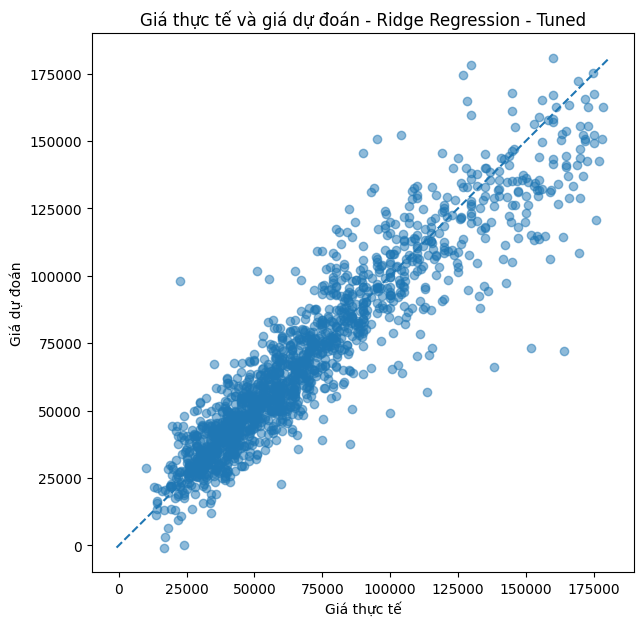

In [ ]:
# 26. BIỂU ĐỒ GIÁ THỰC TẾ VÀ GIÁ DỰ ĐOÁN CỦA MÔ HÌNH CUỐI CÙNG

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_final, alpha=0.5)

min_value = min(y_test.min(), y_pred_final.min())
max_value = max(y_test.max(), y_pred_final.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Giá thực tế")
plt.ylabel("Giá dự đoán")
plt.title(f"Giá thực tế và giá dự đoán - {best_final_model_name}")
plt.show()

## 27. Dự đoán thử giá laptop mới

In [ ]:
# 27. DỰ ĐOÁN THỬ GIÁ LAPTOP MỚI

new_laptop = pd.DataFrame([X_test.iloc[0].copy()])

for col in new_laptop.columns:
    col_lower = col.lower()

    if "ram" in col_lower and pd.api.types.is_numeric_dtype(X_train[col]):
        new_laptop[col] = 16

    if "ssd" in col_lower and pd.api.types.is_numeric_dtype(X_train[col]):
        new_laptop[col] = 512

    if "weight" in col_lower and pd.api.types.is_numeric_dtype(X_train[col]):
        new_laptop[col] = 1.8

    if "display" in col_lower and pd.api.types.is_numeric_dtype(X_train[col]):
        new_laptop[col] = 15.6

new_laptop = new_laptop[X_train.columns]

predicted_price = best_final_model.predict(new_laptop)[0]

print("Giá laptop dự đoán:", round(predicted_price, 2))

Giá laptop dự đoán: 88479.81


### Nhận xét:

Bước này minh họa cách sử dụng mô hình tốt nhất cuối cùng để dự đoán giá cho một laptop mới. Dữ liệu đầu vào cần có cùng cấu trúc cột với tập huấn luyện để pipeline có thể xử lý đúng.

Kết quả dự đoán chỉ mang tính tham khảo, vì giá laptop thực tế còn phụ thuộc vào thương hiệu, thị trường, thời điểm bán và các yếu tố kinh doanh khác.

## 28 . Lưu mô hình

In [ ]:
# 28. LƯU MÔ HÌNH

import joblib

joblib.dump(best_final_model, "best_laptop_price_regression_model.pkl")

print("Đã lưu mô hình hồi quy tốt nhất vào file best_laptop_price_regression_model.pkl")

Đã lưu mô hình hồi quy tốt nhất vào file best_laptop_price_regression_model.pkl


# KẾT LUẬN TỔNG QUAN

Trong bài toán hồi quy này, em đã xây dựng mô hình học máy để dự đoán giá laptop dựa trên các đặc trưng liên quan đến thương hiệu, dòng máy, cấu hình phần cứng, màn hình, hệ điều hành, pin, cổng kết nối và trạng thái sản phẩm. Biến mục tiêu là `Price (Rs)`, có dạng giá trị số liên tục, nên đây là bài toán hồi quy.

Quy trình thực hiện gồm các bước chính: nạp dữ liệu, khám phá dữ liệu, kiểm tra giá trị thiếu, xử lý biến mục tiêu, phân tích phân bố giá, xử lý ngoại lệ, trích xuất thêm đặc trưng số từ các cột văn bản, loại bỏ một số cột thiếu quá nhiều dữ liệu, chia tập train/test, xây dựng pipeline tiền xử lý, huấn luyện nhiều mô hình hồi quy, tối ưu Ridge Regression và đánh giá kết quả.

Các mô hình được sử dụng gồm Dummy Regressor, Linear Regression, Ridge Regression, Lasso Regression, KNN Regressor, Decision Tree Regressor và Random Forest Regressor. Trong đó, Dummy Regressor được dùng làm mô hình cơ sở để so sánh, giúp kiểm tra các mô hình học máy có thực sự học được quy luật từ dữ liệu hay không.

Sau khi so sánh các mô hình, Ridge Regression là mô hình tốt nhất ban đầu. Vì vậy, bài làm tiếp tục tối ưu tham số `alpha` bằng GridSearchCV. Sau khi tối ưu và so sánh lại, mô hình tốt nhất cuối cùng được sử dụng để phân tích sâu hơn, dự đoán thử và lưu mô hình.

Kết quả cho thấy mô hình hồi quy tốt nhất có khả năng dự đoán giá laptop tương đối tốt dựa trên các đặc trưng đầu vào. So với Dummy Regressor, mô hình học máy cho sai số thấp hơn rõ rệt, chứng tỏ mô hình đã học được mối quan hệ giữa cấu hình laptop và giá bán.

Biểu đồ giá thực tế và giá dự đoán cho thấy phần lớn các điểm dữ liệu nằm gần đường chéo, thể hiện mô hình có khả năng dự đoán tương đối ổn định. Phân tích phần dư cũng cho thấy sai số chủ yếu tập trung quanh 0, mặc dù vẫn còn một số mẫu có sai số lớn.

Nhìn chung, mô hình hồi quy tốt nhất có thể được sử dụng để hỗ trợ ước lượng giá laptop dựa trên thông tin cấu hình và đặc điểm sản phẩm. Tuy nhiên, kết quả dự đoán chỉ mang tính tham khảo trong phạm vi học tập và phân tích dữ liệu, vì giá laptop thực tế còn phụ thuộc vào thương hiệu, thị trường, thời điểm bán, chính sách khuyến mãi và các yếu tố kinh doanh khác.